# Feature Engineering Demo

This notebook demonstrates Valorem's Feature Engineering pipeline (Phase 5, Milestones 13-15):

1. **Node Features** - IV changes, skew slope, term slope, microstructure
2. **Global Features** - Returns, realized volatility
3. **Macro Features** - FRED data transforms, release-time alignment
4. **Feature Engine** - Orchestration and time-aware merging
5. **Anti-Leakage Validation** - Ensure no future data contamination

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Feature generators
from src.features.node.iv_features import IVFeatureGenerator, IVFeatureConfig
from src.features.node.surface import SurfaceFeatureGenerator, SurfaceFeatureConfig
from src.features.node.microstructure import MicrostructureFeatureGenerator, MicrostructureConfig
from src.features.global_.returns import ReturnsGenerator, ReturnsConfig
from src.features.global_.realized_vol import RealizedVolGenerator, RealizedVolConfig
from src.features.macro.transforms import MacroTransformGenerator, MacroTransformConfig
from src.features.validators import FeatureValidator
from src.config.constants import SurfaceConstants

pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
print("Feature Engineering components loaded successfully!")

## Generate Synthetic Data

First, we'll create realistic synthetic data to demonstrate the feature generators.

In [ ]:
# Generate 60 trading days of surface snapshots
def generate_surface_data(n_days=60):
    """Generate synthetic surface snapshot data."""
    
    delta_buckets = ['P10', 'P25', 'P40', 'ATM', 'C40', 'C25', 'C10']
    tenors_days = list(SurfaceConstants.TENOR_DAYS_DEFAULT)
    
    # Generate timestamps (skip weekends)
    base_date = datetime(2024, 1, 2, 16, 0, 0)
    timestamps = []
    current = base_date
    for _ in range(n_days):
        timestamps.append(current)
        current += timedelta(days=1)
        while current.weekday() >= 5:
            current += timedelta(days=1)
    
    # Base IV by bucket (smile pattern)
    bucket_base_iv = {
        'P10': 0.28, 'P25': 0.24, 'P40': 0.21,
        'ATM': 0.20,
        'C40': 0.21, 'C25': 0.23, 'C10': 0.26,
    }
    
    # Delta values by bucket
    bucket_deltas = {
        'P10': -0.10, 'P25': -0.25, 'P40': -0.40,
        'ATM': 0.50,
        'C40': 0.40, 'C25': 0.25, 'C10': 0.10,
    }
    
    rows = []
    iv_regime = 0  # Track IV regime shifts
    
    for t_idx, ts in enumerate(timestamps):
        # Add regime shifts (simulating market stress)
        if t_idx == 30:
            iv_regime = 0.05  # Volatility spike
        elif t_idx == 45:
            iv_regime = 0  # Return to normal
        
        for tenor in tenors_days:
            # Term structure adjustment
            term_adj = 0.02 * np.sqrt(tenor / 30)
            
            for bucket in delta_buckets:
                # IV with smile + term structure + regime + noise
                base_iv = bucket_base_iv[bucket]
                noise = np.random.randn() * 0.005
                iv_mid = base_iv + term_adj + iv_regime + noise
                
                # Greeks
                delta = bucket_deltas[bucket]
                gamma = 0.05 / np.sqrt(tenor / 365)
                vega = 0.15 * np.sqrt(tenor / 365)
                theta = -0.01 * iv_mid / np.sqrt(tenor / 365)
                
                # Spread (wider for OTM options)
                spread_pct = 0.02 + 0.03 * abs(abs(delta) - 0.5)
                
                # Volume and OI
                volume = int(np.random.exponential(200))
                open_interest = int(np.random.exponential(1000))
                
                rows.append({
                    'ts_utc': ts,
                    'tenor_days': tenor,
                    'delta_bucket': bucket,
                    'iv_mid': iv_mid,
                    'iv_bid': iv_mid - spread_pct/2,
                    'iv_ask': iv_mid + spread_pct/2,
                    'delta': delta,
                    'gamma': gamma,
                    'vega': vega,
                    'theta': theta,
                    'spread_pct': spread_pct,
                    'volume': volume,
                    'open_interest': open_interest,
                })
    
    return pd.DataFrame(rows)

# Generate underlying price data
def generate_underlying_data(timestamps):
    """Generate synthetic underlying price series."""
    n = len(timestamps)
    
    # GBM simulation
    S0 = 480.0
    mu = 0.10  # 10% annual drift
    sigma = 0.18  # 18% annual vol
    dt = 1/252
    
    returns = np.random.randn(n) * sigma * np.sqrt(dt) + mu * dt
    prices = S0 * np.cumprod(1 + returns)
    
    return pd.DataFrame({
        'ts_utc': timestamps,
        'close': prices,
    })

# Generate macro data (SOFR)
def generate_macro_data(timestamps):
    """Generate synthetic SOFR data."""
    n = len(timestamps)
    
    # Random walk around 5%
    rate = 5.0
    rates = [rate]
    for _ in range(n - 1):
        rate += np.random.randn() * 0.02
        rate = max(0.1, min(10.0, rate))  # Bound between 0.1% and 10%
        rates.append(rate)
    
    return pd.DataFrame({
        'obs_date': [ts.date() for ts in timestamps],
        'value': rates,
        'series_id': 'SOFR',
    })

# Generate all data
surface_df = generate_surface_data(60)
timestamps = sorted(surface_df['ts_utc'].unique())
underlying_df = generate_underlying_data(timestamps)
macro_df = generate_macro_data(timestamps)

print(f"Surface data: {len(surface_df)} rows, {len(timestamps)} timestamps")
print(f"Underlying data: {len(underlying_df)} rows")
print(f"Macro data: {len(macro_df)} rows")

## 1. Node Features - IV Changes

The `IVFeatureGenerator` computes IV changes, rolling volatility, and z-scores over configurable windows.

In [32]:
# Initialize IV feature generator with config
iv_config = IVFeatureConfig(
    change_periods=[1, 5, 10],      # IV changes over 1, 5, 10 days
    rolling_windows=[5, 10, 21],    # Rolling volatility windows
    min_periods=1
)
iv_gen = IVFeatureGenerator(config=iv_config)

# Generate features
iv_features = iv_gen.generate(surface_df)

print("IV Features Generated:")
print(iv_features.columns.tolist())
print(f"\nShape: {iv_features.shape}")
print(f"\nSample (ATM, 30D):")
sample = iv_features[
    (iv_features['delta_bucket'] == 'ATM') & 
    (iv_features['tenor_days'] == 30)
].head(10)
print(sample[['ts_utc', 'iv_mid', 'iv_change_1d', 'iv_change_5d', 'iv_change_10d']].to_string(index=False))

IV Features Generated:
['ts_utc', 'tenor_days', 'delta_bucket', 'iv_mid', 'iv_bid', 'iv_ask', 'delta', 'gamma', 'vega', 'theta', 'spread_pct', 'volume', 'open_interest', 'iv_change_1d', 'iv_change_5d', 'iv_change_10d', 'iv_vol_5d', 'iv_vol_10d', 'iv_vol_21d', 'iv_zscore_5d', 'iv_zscore_10d', 'iv_zscore_21d']

Shape: (2520, 22)

Sample (ATM, 30D):
             ts_utc  iv_mid  iv_change_1d  iv_change_5d  iv_change_10d
2024-01-02 16:00:00  0.2164           NaN           NaN            NaN
2024-01-03 16:00:00  0.2217        0.0053           NaN            NaN
2024-01-04 16:00:00  0.2239        0.0021           NaN            NaN
2024-01-05 16:00:00  0.2201       -0.0038           NaN            NaN
2024-01-08 16:00:00  0.2238        0.0037           NaN            NaN
2024-01-09 16:00:00  0.2239        0.0001        0.0075            NaN
2024-01-10 16:00:00  0.2222       -0.0016        0.0005            NaN
2024-01-11 16:00:00  0.2201       -0.0021       -0.0037            NaN
2024-01-12 1

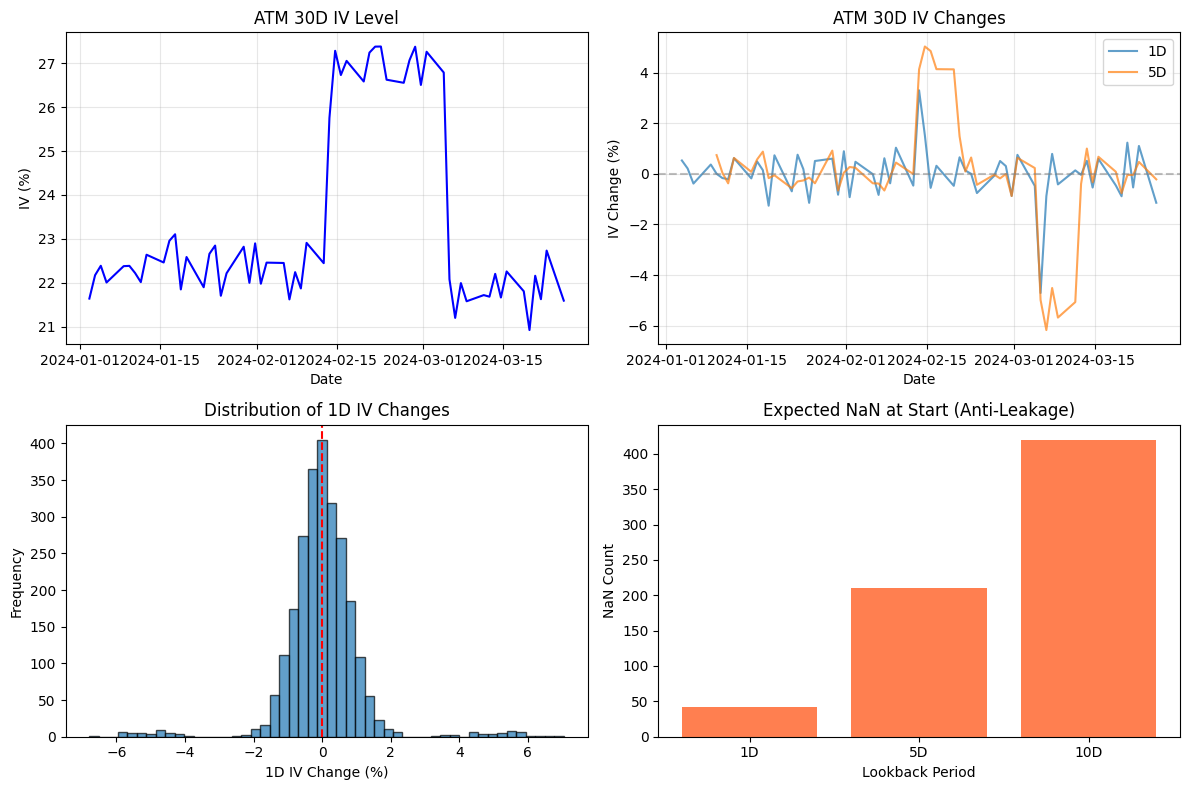

In [33]:
# Visualize IV changes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ATM 30D IV level
atm_30 = iv_features[
    (iv_features['delta_bucket'] == 'ATM') & 
    (iv_features['tenor_days'] == 30)
].copy()

axes[0, 0].plot(atm_30['ts_utc'], atm_30['iv_mid'] * 100, 'b-', linewidth=1.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('IV (%)')
axes[0, 0].set_title('ATM 30D IV Level')
axes[0, 0].grid(True, alpha=0.3)

# IV Changes
axes[0, 1].plot(atm_30['ts_utc'], atm_30['iv_change_1d'] * 100, label='1D', alpha=0.7)
axes[0, 1].plot(atm_30['ts_utc'], atm_30['iv_change_5d'] * 100, label='5D', alpha=0.7)
axes[0, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('IV Change (%)')
axes[0, 1].set_title('ATM 30D IV Changes')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution of 1D changes
axes[1, 0].hist(iv_features['iv_change_1d'].dropna() * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('1D IV Change (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of 1D IV Changes')

# NaN count by lookback
nan_counts = {
    '1D': iv_features['iv_change_1d'].isna().sum(),
    '5D': iv_features['iv_change_5d'].isna().sum(),
    '10D': iv_features['iv_change_10d'].isna().sum(),
}
axes[1, 1].bar(nan_counts.keys(), nan_counts.values(), color='coral')
axes[1, 1].set_xlabel('Lookback Period')
axes[1, 1].set_ylabel('NaN Count')
axes[1, 1].set_title('Expected NaN at Start (Anti-Leakage)')

plt.tight_layout()
plt.show()

## 2. Node Features - Skew and Term Slope

These features capture the shape of the volatility surface.

In [34]:
# Surface feature generator (produces skew_slope, term_slope, atm_spread, curvature)
surface_gen = SurfaceFeatureGenerator()
surface_features = surface_gen.generate(surface_df)

print("Surface Features Generated:")
print(f"  Columns: {[c for c in surface_features.columns if c not in surface_df.columns]}")
print(f"  Sample skew slopes: {surface_features['skew_slope'].dropna().head(5).values}")
print(f"  Sample term slopes: {surface_features['term_slope'].dropna().head(5).values}")

Surface Features Generated:
  Columns: ['skew_slope', 'skew_convexity', 'term_slope', 'atm_spread', 'curvature']
  Sample skew slopes: [-0.03611425 -0.03611425 -0.03611425 -0.03611425 -0.03611425]
  Sample term slopes: [0.00975867 0.01062798 0.01110177 0.00993134 0.01307134]


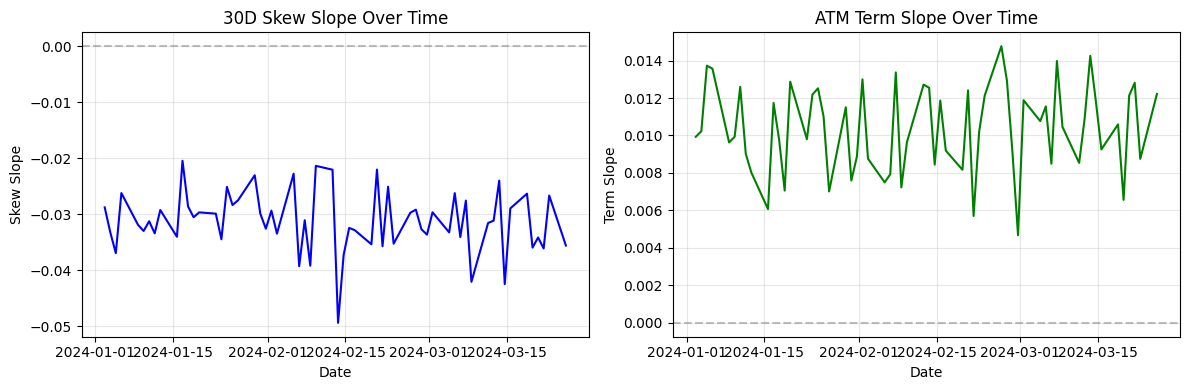

In [35]:
# Visualize surface shape features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Skew slope over time (30D tenor)
skew_30 = surface_features[surface_features['tenor_days'] == 30].copy()
skew_30_agg = skew_30.groupby('ts_utc')['skew_slope'].first()

axes[0].plot(skew_30_agg.index, skew_30_agg.values, 'b-', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Skew Slope')
axes[0].set_title('30D Skew Slope Over Time')
axes[0].grid(True, alpha=0.3)

# Term slope over time (ATM bucket)
term_atm = surface_features[surface_features['delta_bucket'] == 'ATM'].copy()
term_atm_agg = term_atm.groupby('ts_utc')['term_slope'].first()

axes[1].plot(term_atm_agg.index, term_atm_agg.values, 'g-', linewidth=1.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Term Slope')
axes[1].set_title('ATM Term Slope Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Global Features - Returns and Realized Volatility

These features are computed from the underlying price series.

In [36]:
# Returns generator (uses config object)
returns_config = ReturnsConfig(periods=[1, 5, 10, 21])
returns_gen = ReturnsGenerator(config=returns_config)
returns_features = returns_gen.generate(underlying_df)

# Realized vol generator (uses config object)
# Set min_periods to match smallest window to ensure proper warm-up
rv_config = RealizedVolConfig(
    variance_windows=[5, 10, 21],
    min_periods=5,  # Require at least 5 observations before computing RV
)
rv_gen = RealizedVolGenerator(config=rv_config)
rv_features = rv_gen.generate(underlying_df)

print("Returns Features:")
print(f"  Columns: {returns_features.columns.tolist()}")
print(f"  Shape: {returns_features.shape}")

print("\nRealized Vol Features:")
print(f"  Columns: {rv_features.columns.tolist()}")
print(f"  Shape: {rv_features.shape}")

Returns Features:
  Columns: ['ts_utc', 'close', 'returns_1d', 'log_returns_1d', 'returns_5d', 'log_returns_5d', 'returns_10d', 'log_returns_10d', 'returns_21d', 'log_returns_21d']
  Shape: (60, 10)

Realized Vol Features:
  Columns: ['ts_utc', 'close', 'rv_5d', 'realized_vol_5d', 'rv_10d', 'realized_vol_10d', 'rv_21d', 'realized_vol_21d', 'vol_of_vol_21d', 'drawdown', 'max_drawdown_252d']
  Shape: (60, 11)


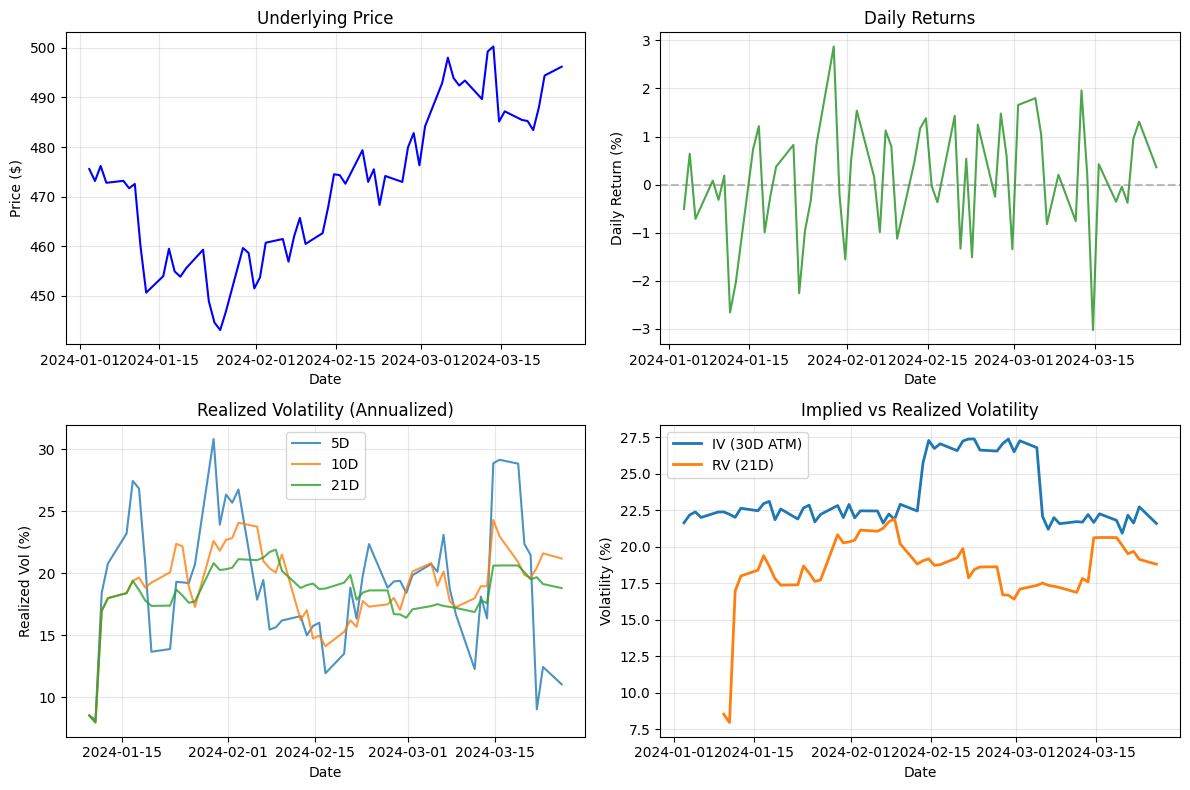

In [37]:
# Visualize global features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Underlying price
axes[0, 0].plot(underlying_df['ts_utc'], underlying_df['close'], 'b-', linewidth=1.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].set_title('Underlying Price')
axes[0, 0].grid(True, alpha=0.3)

# Returns
axes[0, 1].plot(returns_features['ts_utc'], returns_features['returns_1d'] * 100, 'g-', alpha=0.7)
axes[0, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Daily Return (%)')
axes[0, 1].set_title('Daily Returns')
axes[0, 1].grid(True, alpha=0.3)

# Realized volatility (use realized_vol columns, not rv which is variance)
axes[1, 0].plot(rv_features['ts_utc'], rv_features['realized_vol_5d'] * 100, label='5D', alpha=0.8)
axes[1, 0].plot(rv_features['ts_utc'], rv_features['realized_vol_10d'] * 100, label='10D', alpha=0.8)
axes[1, 0].plot(rv_features['ts_utc'], rv_features['realized_vol_21d'] * 100, label='21D', alpha=0.8)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Realized Vol (%)')
axes[1, 0].set_title('Realized Volatility (Annualized)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# IV vs RV comparison (need to merge)
atm_30_iv = surface_df[
    (surface_df['delta_bucket'] == 'ATM') & 
    (surface_df['tenor_days'] == 30)
][['ts_utc', 'iv_mid']].copy()

# Merge with RV (use realized_vol_21d for comparison with IV)
comparison = pd.merge(atm_30_iv, rv_features[['ts_utc', 'realized_vol_21d']], on='ts_utc')

axes[1, 1].plot(comparison['ts_utc'], comparison['iv_mid'] * 100, label='IV (30D ATM)', linewidth=2)
axes[1, 1].plot(comparison['ts_utc'], comparison['realized_vol_21d'] * 100, label='RV (21D)', linewidth=2)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].set_title('Implied vs Realized Volatility')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Macro Features - FRED Data Transforms

The `MacroTransformGenerator` creates level, change, and z-score features from FRED data.

In [38]:
# Macro transform generator (uses config object and series_id)
macro_config = MacroTransformConfig(
    include_level=True,
    include_change_1w=True,
    include_change_1m=True,
    include_zscore=True,
    zscore_window=63,  # ~3 months
    percent_to_decimal=True,
    percent_series=['SOFR'],  # Convert SOFR from % to decimal
)
macro_gen = MacroTransformGenerator(config=macro_config)

# Generate features for SOFR series
macro_features = macro_gen.generate(macro_df, series_id='SOFR')

print("Macro Features Generated:")
print(f"  Columns: {macro_features.columns.tolist()}")
print(f"  Shape: {macro_features.shape}")
print(f"\nSample:")
print(macro_features.head(10).to_string(index=False))

Macro Features Generated:
  Columns: ['ts_utc', 'SOFR_level', 'SOFR_change_1w', 'SOFR_change_1m', 'SOFR_zscore']
  Shape: (60, 5)

Sample:
    ts_utc  SOFR_level  SOFR_change_1w  SOFR_change_1m  SOFR_zscore
2024-01-03      0.0500             NaN             NaN          NaN
2024-01-04      0.0499             NaN             NaN      -0.7071
2024-01-05      0.0499             NaN             NaN      -0.6735
2024-01-06      0.0499             NaN             NaN      -0.5018
2024-01-09      0.0498             NaN             NaN      -1.6653
2024-01-10      0.0499             NaN             NaN      -0.2915
2024-01-11      0.0500             NaN             NaN       0.7879
2024-01-12      0.0503          0.0003             NaN       2.1796
2024-01-13      0.0505          0.0006             NaN       2.1609
2024-01-16      0.0504          0.0005             NaN       1.3319


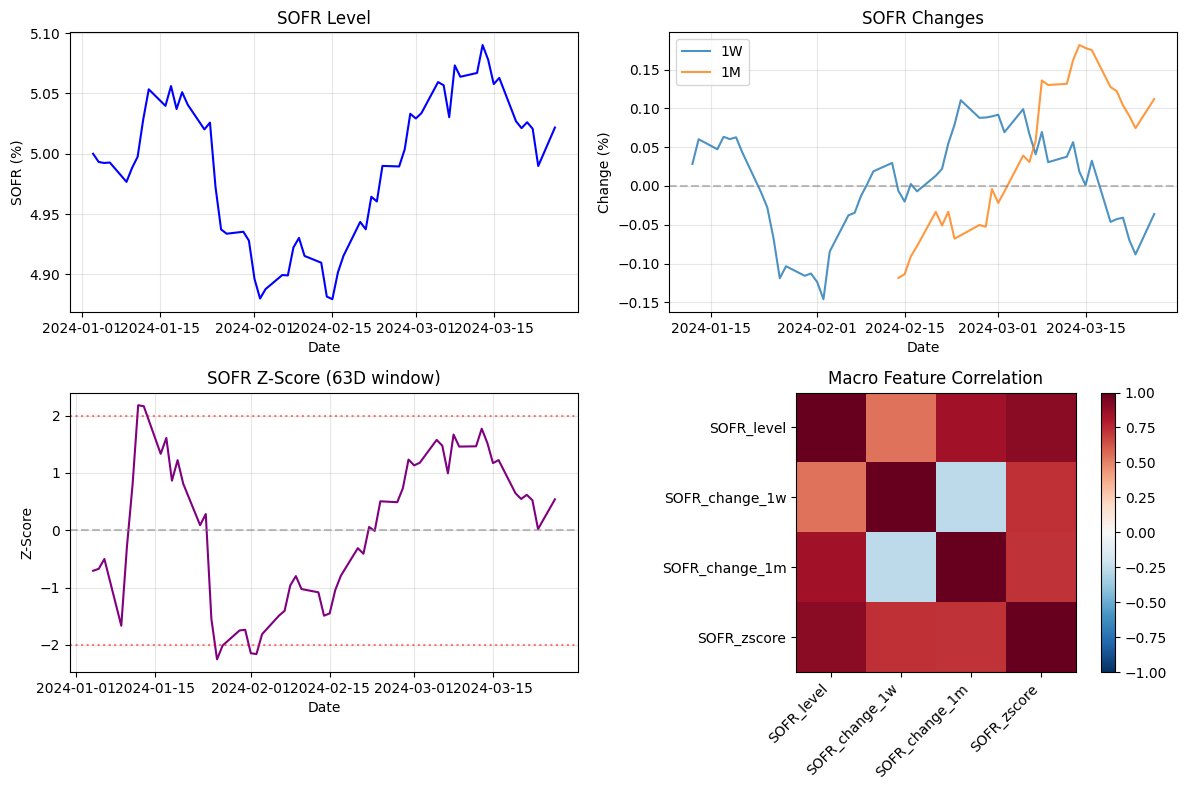

In [39]:
# Visualize macro features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# SOFR level
axes[0, 0].plot(macro_features['ts_utc'], macro_features['SOFR_level'] * 100, 'b-', linewidth=1.5)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('SOFR (%)')
axes[0, 0].set_title('SOFR Level')
axes[0, 0].grid(True, alpha=0.3)

# SOFR changes
axes[0, 1].plot(macro_features['ts_utc'], macro_features['SOFR_change_1w'] * 100, label='1W', alpha=0.8)
axes[0, 1].plot(macro_features['ts_utc'], macro_features['SOFR_change_1m'] * 100, label='1M', alpha=0.8)
axes[0, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Change (%)')
axes[0, 1].set_title('SOFR Changes')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# SOFR z-score
if 'SOFR_zscore' in macro_features.columns:
    axes[1, 0].plot(macro_features['ts_utc'], macro_features['SOFR_zscore'], 'purple', linewidth=1.5)
    axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 0].axhline(2, color='red', linestyle=':', alpha=0.5)
    axes[1, 0].axhline(-2, color='red', linestyle=':', alpha=0.5)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Z-Score')
    axes[1, 0].set_title('SOFR Z-Score (63D window)')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Z-Score not computed\n(need more data)', 
                    ha='center', va='center', transform=axes[1, 0].transAxes)

# Feature correlation
feature_cols = [c for c in macro_features.columns if c != 'ts_utc']
corr = macro_features[feature_cols].corr()
im = axes[1, 1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(len(feature_cols)))
axes[1, 1].set_xticklabels(feature_cols, rotation=45, ha='right')
axes[1, 1].set_yticks(range(len(feature_cols)))
axes[1, 1].set_yticklabels(feature_cols)
axes[1, 1].set_title('Macro Feature Correlation')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 5. Anti-Leakage Validation

The `FeatureValidator` ensures no future data contamination in our features.

In [40]:
# Combine all features into a panel
panel = iv_features.copy()

# Merge surface features (skew_slope, term_slope, atm_spread, curvature)
panel = pd.merge(
    panel,
    surface_features[['ts_utc', 'tenor_days', 'delta_bucket', 'skew_slope', 'term_slope', 'atm_spread', 'curvature']],
    on=['ts_utc', 'tenor_days', 'delta_bucket'],
    how='left'
)

# Merge global features (time-aware)
panel = pd.merge_asof(
    panel.sort_values('ts_utc'),
    rv_features[['ts_utc', 'rv_5d', 'rv_10d', 'rv_21d']].sort_values('ts_utc'),
    on='ts_utc',
    direction='backward'  # Only use past data!
)

print(f"Combined panel shape: {panel.shape}")
print(f"Features: {panel.columns.tolist()}")

Combined panel shape: (2520, 29)
Features: ['ts_utc', 'tenor_days', 'delta_bucket', 'iv_mid', 'iv_bid', 'iv_ask', 'delta', 'gamma', 'vega', 'theta', 'spread_pct', 'volume', 'open_interest', 'iv_change_1d', 'iv_change_5d', 'iv_change_10d', 'iv_vol_5d', 'iv_vol_10d', 'iv_vol_21d', 'iv_zscore_5d', 'iv_zscore_10d', 'iv_zscore_21d', 'skew_slope', 'term_slope', 'atm_spread', 'curvature', 'rv_5d', 'rv_10d', 'rv_21d']


In [41]:
# Validate for leakage
validator = FeatureValidator()

# Define rolling features and their expected lookback
# Note: rv_* features use min_periods=5 (configured above), not the full window
rolling_features = {
    'iv_change_1d': 1,
    'iv_change_5d': 5,
    'iv_change_10d': 10,
    'rv_5d': 5,      # min_periods=5
    'rv_10d': 5,     # min_periods=5 (not 10)
    'rv_21d': 5,     # min_periods=5 (not 21)
}

# Check that rolling features have expected NaN at start
print("Anti-Leakage Validation Results:")
print("=" * 50)

validation_passed = True
for feature, lookback in rolling_features.items():
    if feature not in panel.columns:
        continue
    
    # Get first N timestamps
    timestamps = sorted(panel['ts_utc'].unique())
    early_timestamps = timestamps[:lookback]
    
    # Check if feature is NaN for early timestamps
    early_data = panel[panel['ts_utc'].isin(early_timestamps)]
    nan_rate = early_data[feature].isna().mean()
    
    status = "PASS" if nan_rate > 0.9 else "FAIL"
    if nan_rate <= 0.9:
        validation_passed = False
    
    print(f"{feature} (lookback={lookback}): {nan_rate*100:.1f}% NaN in first {lookback} days - {status}")

print("=" * 50)
print(f"\nOverall: {'No leakage detected' if validation_passed else 'Potential leakage detected'}")

Anti-Leakage Validation Results:
iv_change_1d (lookback=1): 100.0% NaN in first 1 days - PASS
iv_change_5d (lookback=5): 100.0% NaN in first 5 days - PASS
iv_change_10d (lookback=10): 100.0% NaN in first 10 days - PASS
rv_5d (lookback=5): 100.0% NaN in first 5 days - PASS
rv_10d (lookback=5): 100.0% NaN in first 5 days - PASS
rv_21d (lookback=5): 100.0% NaN in first 5 days - PASS

Overall: No leakage detected


In [42]:
# Feature range validation
print("\nFeature Range Validation:")
print("=" * 50)

feature_ranges = {
    'iv_mid': (0.0, 2.0),      # IV should be 0-200%
    'delta': (-1.0, 1.0),      # Delta bounded
    'spread_pct': (0.0, 1.0),  # Spread as fraction
    'rv_5d': (0.0, 2.0),       # RV should be 0-200%
    'rv_21d': (0.0, 2.0),
}

for feature, (min_val, max_val) in feature_ranges.items():
    if feature not in panel.columns:
        continue
    
    data = panel[feature].dropna()
    actual_min = data.min()
    actual_max = data.max()
    
    in_range = (actual_min >= min_val) and (actual_max <= max_val)
    status = "✅" if in_range else "⚠️"
    
    print(f"{feature}: [{actual_min:.4f}, {actual_max:.4f}] (expected [{min_val}, {max_val}]) {status}")


Feature Range Validation:
iv_mid: [0.1982, 0.3817] (expected [0.0, 2.0]) ✅
delta: [-0.4000, 0.5000] (expected [-1.0, 1.0]) ✅
spread_pct: [0.0200, 0.0320] (expected [0.0, 1.0]) ✅
rv_5d: [0.0067, 0.0951] (expected [0.0, 2.0]) ✅
rv_21d: [0.0063, 0.0480] (expected [0.0, 2.0]) ✅


## Summary

This notebook demonstrated the key components of Valorem's feature engineering pipeline:

| Component | Features Generated | Key Properties |
|-----------|-------------------|----------------|
| **IVFeatureGenerator** | iv_change_{n}d, iv_vol_{n}d, iv_zscore_{n}d | Rolling, NaN at start |
| **SurfaceFeatureGenerator** | skew_slope, term_slope, atm_spread, curvature | Cross-sectional |
| **ReturnsGenerator** | returns_{n}d, log_returns_{n}d | Rolling, NaN at start |
| **RealizedVolGenerator** | rv_{n}d, realized_vol_{n}d | Rolling, NaN at start |
| **MacroTransformGenerator** | {series}_level, _change_1w, _change_1m, _zscore | Time-aligned |

**Anti-Leakage Safeguards:**
- Rolling features have NaN for early timestamps (lookback not satisfied)
- `merge_asof` with `direction='backward'` ensures only past data is used
- FeatureValidator checks for expected NaN patterns and value ranges

In [43]:
print("=" * 60)
print("FEATURE ENGINEERING DEMO COMPLETE")
print("=" * 60)
print(f"\nTotal features in panel: {len([c for c in panel.columns if c not in ['ts_utc', 'tenor_days', 'delta_bucket']])}")
print(f"Total observations: {len(panel)}")
print(f"Date range: {panel['ts_utc'].min()} to {panel['ts_utc'].max()}")
print(f"\nFeature completeness (non-NaN rate):")
for col in panel.columns:
    if col not in ['ts_utc', 'tenor_days', 'delta_bucket']:
        rate = panel[col].notna().mean() * 100
        print(f"  {col}: {rate:.1f}%")

FEATURE ENGINEERING DEMO COMPLETE

Total features in panel: 26
Total observations: 2520
Date range: 2024-01-02 16:00:00 to 2024-03-25 16:00:00

Feature completeness (non-NaN rate):
  iv_mid: 100.0%
  iv_bid: 100.0%
  iv_ask: 100.0%
  delta: 100.0%
  gamma: 100.0%
  vega: 100.0%
  theta: 100.0%
  spread_pct: 100.0%
  volume: 100.0%
  open_interest: 100.0%
  iv_change_1d: 98.3%
  iv_change_5d: 91.7%
  iv_change_10d: 83.3%
  iv_vol_5d: 98.3%
  iv_vol_10d: 98.3%
  iv_vol_21d: 98.3%
  iv_zscore_5d: 98.3%
  iv_zscore_10d: 98.3%
  iv_zscore_21d: 98.3%
  skew_slope: 100.0%
  term_slope: 100.0%
  atm_spread: 100.0%
  curvature: 100.0%
  rv_5d: 91.7%
  rv_10d: 91.7%
  rv_21d: 91.7%
